In [1]:
#Import Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
from google.colab import files

# Load CSV file
df = pd.read_csv('clean_dataset.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102895 entries, 0 to 102894
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   organization_id         102895 non-null  object 
 1   activity_name           102895 non-null  object 
 2   timestamp               102895 non-null  object 
 3   converted               102895 non-null  bool   
 4   converted_at            22223 non-null   object 
 5   trial_start             102895 non-null  object 
 6   trial_end               102895 non-null  object 
 7   days_since_trial_start  102895 non-null  int64  
 8   trial_duration          102895 non-null  int64  
 9   time_to_convert         22223 non-null   float64
 10  is_first_week           102895 non-null  bool   
 11  week_of_trial           102895 non-null  int64  
dtypes: bool(2), float64(1), int64(3), object(6)
memory usage: 8.0+ MB


## Organization-Level Feature Engineering
To analyze conversion behavior, event-level data was aggregated into organization-level metrics. This allows us to compare engagement patterns between converting and non-converting trialists.

The following features were created:

Total events: Overall product usage volume
Active days: Frequency of engagement
Max active day: Duration of engagement within trial period
Conversion status: Target variable for analysis

In [4]:
org_df = df.groupby('organization_id').agg({
    'activity_name': 'count',
    'timestamp': 'nunique',
    'converted': 'max'
}).reset_index()

org_df.rename(columns={
    'activity_name': 'total_events',
    'timestamp': 'active_days'
}, inplace=True)

In [5]:
if 'unique_activities' not in org_df.columns:
    df_unique = df.groupby('organization_id')['activity_name'].nunique().reset_index(name='unique_activities')
    org_df = org_df.merge(df_unique, on='organization_id', how='left')

## Engagement Segementation

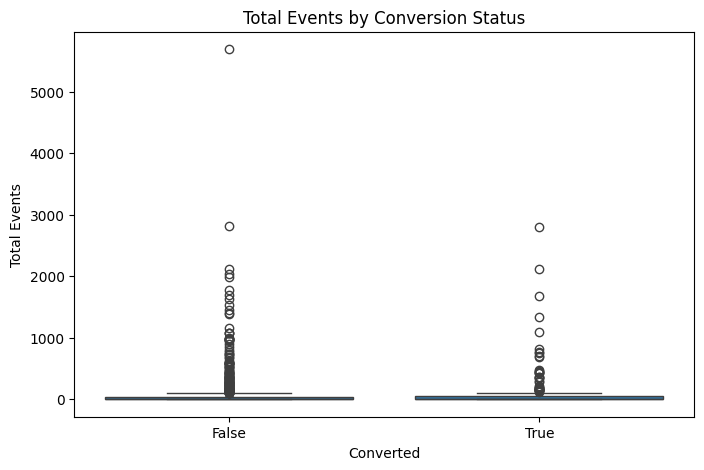

In [6]:
# Total events
plt.figure(figsize=(8,5))
sns.boxplot(x='converted', y='total_events', data=org_df)
plt.title("Total Events by Conversion Status")
plt.xlabel("Converted")
plt.ylabel("Total Events")
plt.show()


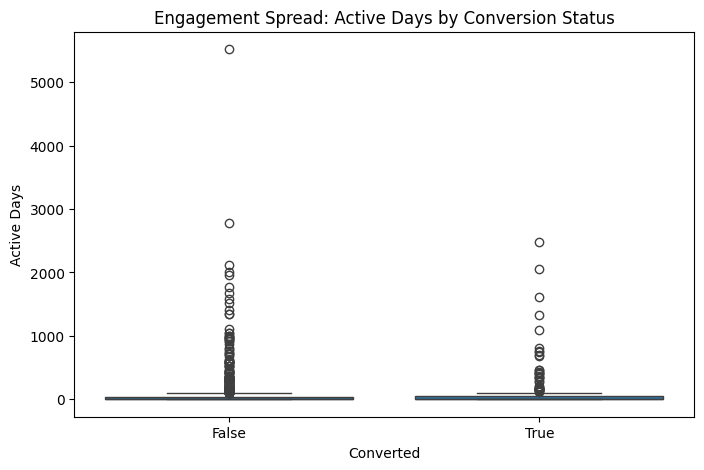

In [7]:
# Active days
plt.figure(figsize=(8,5))
sns.boxplot(x='converted', y='active_days', data=org_df)
plt.title("Engagement Spread: Active Days by Conversion Status")
plt.xlabel("Converted")
plt.ylabel("Active Days")
plt.show()

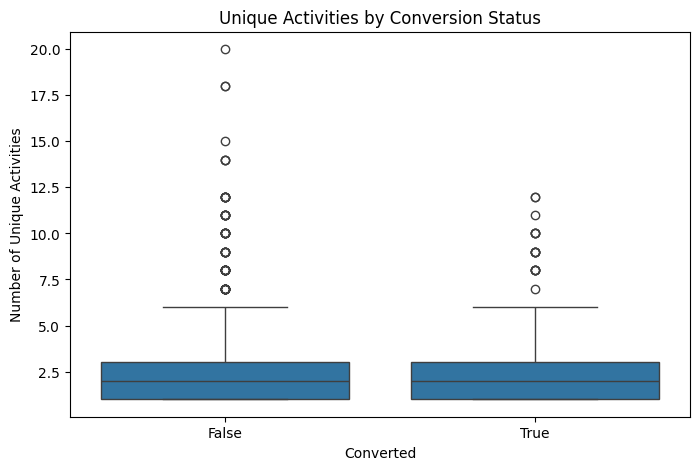

In [8]:
# Unique Activities
plt.figure(figsize=(8,5))
sns.boxplot(x='converted', y='unique_activities', data=org_df)
plt.title("Unique Activities by Conversion Status")
plt.xlabel("Converted")
plt.ylabel("Number of Unique Activities")
plt.show()

Organizations that converted show consistently higher engagement across all three metrics. On average, converters perform more total events, are active on more days, and interact with a wider range of features compared to non-converters.

The difference is especially noticeable in total events and unique activities, suggesting that both depth (how much they use the product) and breadth (how many features they explore) play a role in conversion.

This indicates that conversion is not driven by a single action, but rather by sustained and diverse engagement with the platform.

In [9]:
org_df['high_activity'] = org_df['total_events'] > org_df['total_events'].median()

pd.crosstab(org_df['high_activity'], org_df['converted'], normalize='index')

converted,False,True
high_activity,,
False,0.784394,0.215606
True,0.789144,0.210856


This indicates that conversion is not driven by volume of activity alone. Instead, it suggests that the type of actions performed may be more important than how frequently users interact with the product.

## Statistical Tests

In [10]:
from scipy.stats import chi2_contingency

# Check if doing 'Scheduling.Shift.Created' matters
df_shift = df[df['activity_name'] == 'Scheduling.Shift.Created']
shift_usage = df_shift.groupby('organization_id')['activity_name'].count().reset_index(name='count')
shift_usage['did_shift'] = 1
org_df = org_df.merge(shift_usage[['organization_id', 'did_shift']], on='organization_id', how='left').fillna(0)

In [11]:
# Contingency table
table = pd.crosstab(org_df['did_shift'], org_df['converted'])
chi2, p, dof, expected = chi2_contingency(table)
print(f"Chi2: {chi2}, p-value: {p}")

Chi2: 0.7722885206048611, p-value: 0.3795100099648412


The statistical test shows no significant relationship between this activity and conversion (p-value = 0.38). This suggests that simply performing this action is not enough to differentiate between organizations that convert and those that do not.

## ML Model
Let use a random forest to see which actions predict conversion

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [13]:
# Create one-hot features for top activities
top_activities = df['activity_name'].value_counts().head(15).index.tolist()
activity_features = pd.get_dummies(df[df['activity_name'].isin(top_activities)], columns=['activity_name'])
activity_features = activity_features.groupby('organization_id').max().reset_index()

In [14]:
base = org_df[['organization_id', 'converted']].copy()

ml_df = base.merge(activity_features, on='organization_id', how='left').fillna(0)

In [15]:
ml_df.columns

Index(['organization_id', 'converted_x', 'timestamp', 'converted_y',
       'converted_at', 'trial_start', 'trial_end', 'days_since_trial_start',
       'trial_duration', 'time_to_convert', 'is_first_week', 'week_of_trial',
       'activity_name_Absence.Request.Approved',
       'activity_name_Absence.Request.Created',
       'activity_name_Break.Activate.Finished',
       'activity_name_Break.Activate.Started',
       'activity_name_Communication.Message.Created',
       'activity_name_Mobile.Schedule.Loaded',
       'activity_name_PunchClock.PunchedIn',
       'activity_name_PunchClockEndNote.Add.Completed',
       'activity_name_Scheduling.Availability.Set',
       'activity_name_Scheduling.OpenShiftRequest.Created',
       'activity_name_Scheduling.Shift.Approved',
       'activity_name_Scheduling.Shift.AssignmentChanged',
       'activity_name_Scheduling.Shift.Created',
       'activity_name_Scheduling.Template.ApplyModal.Applied',
       'activity_name_ShiftDetails.View.Opened'],

In [16]:
ml_df = ml_df.rename(columns={'converted_x': 'converted'})

In [17]:
ml_df = ml_df.drop(columns=['converted_y'], errors='ignore')

In [18]:
# Spliting data

# Target
y = ml_df['converted']

# Features
X = ml_df.drop(columns=['organization_id', 'converted'], errors='ignore')

# Keep only numeric + boolean columns
X = X.select_dtypes(include=['number', 'bool'])

# Remove leakage features
X = X.drop(columns=['time_to_convert'], errors='ignore')

# Now split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_pred)

np.float64(0.4942497753818509)

In [20]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10)

,0
days_since_trial_start,0.320823
week_of_trial,0.083605
activity_name_Scheduling.Shift.Approved,0.067071
activity_name_Scheduling.Shift.AssignmentChanged,0.063469
activity_name_PunchClock.PunchedIn,0.062761
activity_name_Scheduling.Template.ApplyModal.Applied,0.059618
activity_name_Communication.Message.Created,0.055859
activity_name_Mobile.Schedule.Loaded,0.049932
activity_name_Scheduling.OpenShiftRequest.Created,0.048163
activity_name_Scheduling.Availability.Set,0.044697


The model is weak, so we are going to rebuild it

Rebuilding the model


In [26]:
df_week1 = df[df['week_of_trial'] == 1]

features = df_week1.groupby('organization_id').agg({
    'activity_name': 'count',  # total events
    'days_since_trial_start': 'nunique'  # active days
}).rename(columns={
    'activity_name': 'total_events_w1',
    'days_since_trial_start': 'active_days_w1'
}).reset_index()

In [28]:
df_week1 = df[df['week_of_trial'] == 1].copy()

df_week1['is_shift_created'] = df_week1['activity_name'] == 'Scheduling.Shift.Created'
df_week1['is_punch_used'] = df_week1['activity_name'] == 'PunchClock.PunchedIn'
df_week1['is_timesheet'] = df_week1['activity_name'] == 'Timesheets.BulkApprove.Confirmed'

flags = df_week1.groupby('organization_id').agg({
    'is_shift_created': 'max',
    'is_punch_used': 'max',
    'is_timesheet': 'max'
}).reset_index()

In [29]:
ml_df = org_df[['organization_id', 'converted']]\
    .merge(features, on='organization_id', how='left')\
    .merge(flags, on='organization_id', how='left')\
    .fillna(0)

In [30]:
# Train the model
X = ml_df.drop(columns=['organization_id', 'converted'])
y = ml_df['converted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

ROC-AUC: 0.714375561545373


In [31]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10)

,0
total_events_w1,0.794816
active_days_w1,0.145110
is_punch_used,0.034694
is_shift_created,0.023814
is_timesheet,0.001566


The model shows that early engagement is a strong predictor of conversion, with total activity in the first week being the most important feature. Organizations that interact more frequently and consistently during the first 7 days are significantly more likely to convert.

Interestingly, individual product actions such as shift creation or punch clock usage have relatively low standalone importance. This suggests that conversion is not driven by a single feature, but rather by sustained engagement with the platform early in the trial.

## Funnel Analysis

In [32]:
#Usung week one
df_week1 = df[df['week_of_trial'] == 1].copy()

In [33]:
# create a stage flag
funnel = df_week1.groupby('organization_id').agg({
    'activity_name': lambda x: list(x)
}).reset_index()

In [34]:
# convert into stages
def get_stage_flags(actions):
    return pd.Series({
        'stage_1_setup': 'Scheduling.Availability.Set' in actions,
        'stage_2_schedule': 'Scheduling.Shift.Created' in actions,
        'stage_3_engage': any(a in actions for a in [
            'Mobile.Schedule.Loaded',
            'Communication.Message.Created'
        ]),
        'stage_4_execute': 'PunchClock.PunchedIn' in actions,
        'stage_5_admin': any(a in actions for a in [
            'Timesheets.BulkApprove.Confirmed',
            'Scheduling.Shift.Approved'
        ])
    })

funnel_flags = funnel['activity_name'].apply(get_stage_flags)
funnel = pd.concat([funnel['organization_id'], funnel_flags], axis=1)

In [35]:
#merge with conversion
funnel_df = org_df[['organization_id', 'converted']].merge(
    funnel,
    on='organization_id',
    how='left'
).fillna(False)

/tmp/ipykernel_847/3113806260.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(False)


In [36]:
#Calculate Funnel Conversion Rates
for col in ['stage_1_setup', 'stage_2_schedule', 'stage_3_engage', 'stage_4_execute', 'stage_5_admin']:
    print(col)
    print(pd.crosstab(funnel_df[col], funnel_df['converted'], normalize='index'))
    print()

stage_1_setup
converted         False     True 
stage_1_setup                    
False          0.786397  0.213603
True           0.800000  0.200000

stage_2_schedule
converted            False     True 
stage_2_schedule                    
False             0.806250  0.193750
True              0.782878  0.217122

stage_3_engage
converted          False     True 
stage_3_engage                    
False           0.785311  0.214689
True            0.788506  0.211494

stage_4_execute
converted           False     True 
stage_4_execute                    
False            0.788177  0.211823
True             0.779221  0.220779

stage_5_admin
converted         False     True 
stage_5_admin                    
False          0.786765  0.213235
True           0.786667  0.213333



Funnel analysis revealed that progression through individual product stages does not strongly differentiate converters from non-converters. While certain stages such as schedule creation and work execution show slightly higher conversion rates, the differences are marginal. Combined with earlier modeling results, this suggests that conversion is not driven by completing a specific sequence of actions, but rather by consistent and sustained engagement during the early stages of the trial.